In [ ]:
# 1. Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, auc

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [ ]:
#Upload Dataset
import pandas as pd
from google.colab import files

uploaded=files.upload()

Saving customer_100k.xlsx to customer_100k.xlsx


In [ ]:
# 2. Load Dataset
import pandas as pd

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)
print(df.head())



NameError: name 'uploaded' is not defined

In [ ]:
# 2.1 Data Cleaning / Preprocessing

# Remove duplicate rows
df = df.drop_duplicates()

# Ensure categorical columns are string
categorical_cols = [
    "gender",
    "region",
    "plan_type",
    "autopay_enabled"
]

numerical_cols = [
    "age",
    "tenure_months",
    "daily_usage_hours",
    "monthly_logins",
    "features_used",
    "monthly_charges",
    "payment_delays",
    "support_tickets",
    "complaint_count",
    "satisfaction_score"
]

df[categorical_cols] = df[categorical_cols].astype(str)

#Remove rows where target is missing
df = df.dropna(subset=["churn"])


# Handle missing values
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

# Check class balance
print("\nChurn Distribution:")
print(df["churn"].value_counts(normalize=True))



Churn Distribution:
churn
0    0.90034
1    0.09966
Name: proportion, dtype: float64


In [ ]:
# 3. Define Target and Features

# Drop customer_id (not useful for prediction)
X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]



In [ ]:
# 4. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# 5. Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [ ]:
# 6. Define Model

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    device="cuda",
    scale_pos_weight=scale_pos_weight
)


In [ ]:
# 7. Create Full Pipeline

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", xgb)
])


In [ ]:
# 8. Hyperparameter Tuning

param_grid = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.2, 0.3],
    "model__min_child_weight": [1, 2, 3, 5],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__reg_lambda": [1, 1.5, 2]
}


random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(
    X_train,
    y_train
)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['age',
                                                                                'tenure_months',
                                                                                'daily_usage_hours',
                                                                                'monthly_logins',
                                                                                'features_used',
                                                                                'monthly_charges',
                                                                                'payment_delays',
                                                                                'support_tickets',
                                                                                'complaint_count',
                                                                                'satisfaction_score']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['gender',
                                                                                '...
                                                                    0.8, 0.9,
                                                                    1.0],
                                        'model__gamma': [0, 0.1, 0.2, 0.3],
                                        'model__learning_rate': [0.005, 0.01,
                                                                 0.03, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5, 6, 7, 8],
                                        'model__min_child_weight': [1, 2, 3, 5],
                                        'model__n_estimators': [200, 400, 600,
                                                                800],
                                        'model__reg_alpha': [0, 0.1, 0.5],
                                        'model__reg_lambda': [1, 1.5, 2],
                                        'model__subsample': [0.6, 0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
# 9. Best Model

best_model = random_search.best_estimator_

print("\nBest Parameters:")
print(random_search.best_params_)


Best Parameters:
{'model__subsample': 0.6, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0.5, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.7}


In [ ]:
# 10. Evaluation

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 0.9561

ROC-AUC Score: 0.8518043005575884

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     18007
           1       0.83      0.70      0.76      1993

    accuracy                           0.96     20000
   macro avg       0.90      0.84      0.87     20000
weighted avg       0.95      0.96      0.95     20000



In [ ]:
# 11. Feature Importance

# Get feature names after preprocessing
ohe = best_model.named_steps["preprocessing"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(encoded_cat_features)

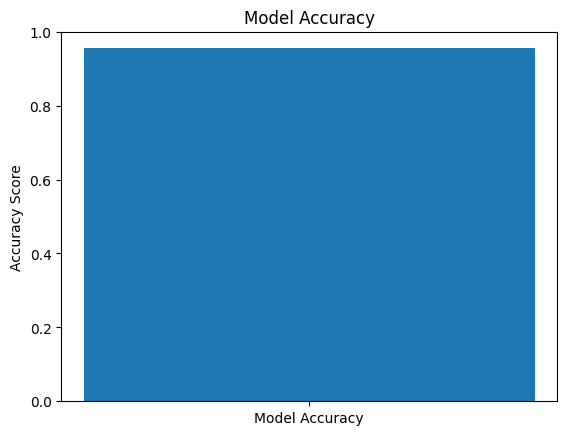

In [ ]:
#Accuracy Plot

accuracy = accuracy_score(y_test, y_pred)

plt.figure()
plt.bar(["Model Accuracy"], [accuracy])
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy Score")
plt.show()


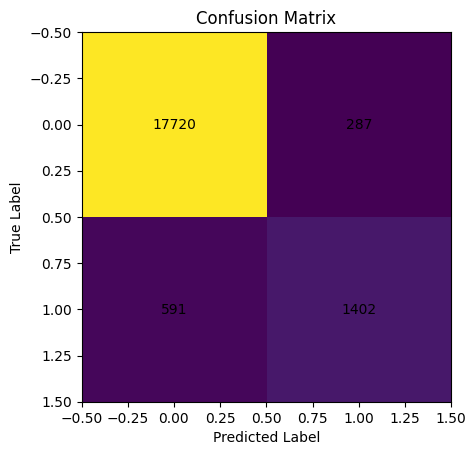

In [ ]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


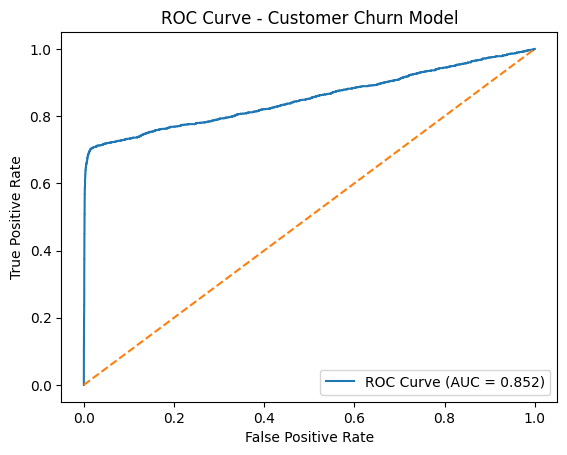

In [ ]:
#ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Model")
plt.legend(loc="lower right")
plt.show()


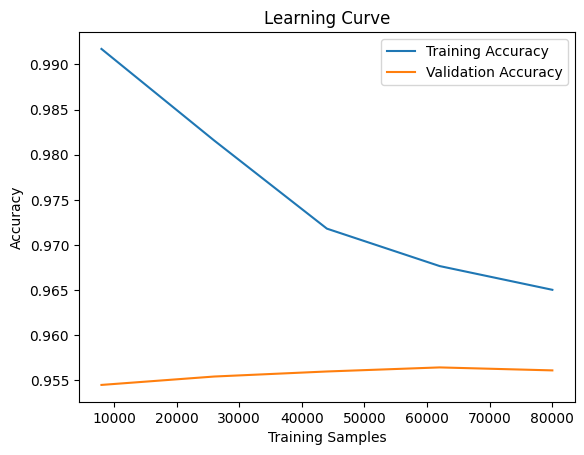

In [ ]:
#Learning Curve

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()


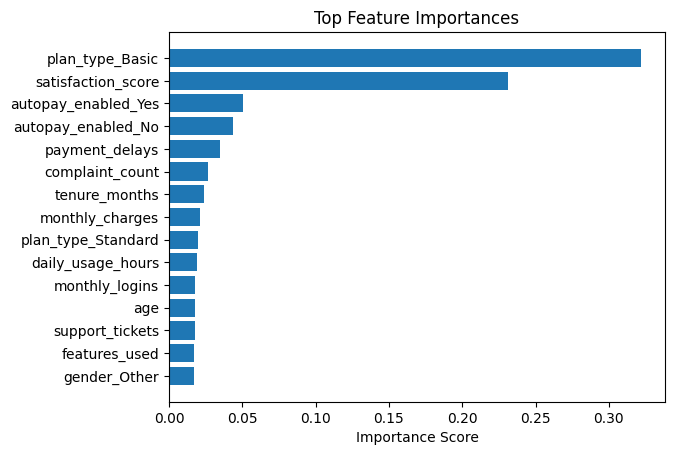

In [ ]:
#Feature Importance Plot (XGBoost)

model = best_model.named_steps["model"]
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top_n = 15  # show top 15 features
top_features = feature_importance_df.head(top_n)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.xlabel("Importance Score")
plt.show()
